# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Nabila Aufa Rafiqi Wardha Qoni'ah
- **Email:** nblafa27@gmail.com
- **ID Dicoding:** CDCC133D6X0156

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- Kategori produk apa yang menghasilkan total revenue tertinggi?
- Bagaimana tren revenue bulanan pada transaksi e-commerce?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

In [3]:
customers_df = pd.read_csv('olist_customers_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv')
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
payments_df = pd.read_csv('olist_order_payments_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
category_df = pd.read_csv('product_category_name_translation.csv')

### Gathering Data

#### Load df ...

In [4]:
customers_df = pd.read_csv('olist_customers_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv')
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
payments_df = pd.read_csv('olist_order_payments_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
category_df = pd.read_csv('product_category_name_translation.csv')

customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
Data yang digunakan berasal dari Brazilian E-Commerce Public Dataset by Olist. Dataset ini terdiri dari beberapa tabel yang saling berkaitan, seperti data pelanggan, pesanan, item pesanan, pembayaran, produk, dan kategori produk. Data tersebut dapat digunakan untuk menganalisis revenue, tren penjualan bulanan, serta perilaku pelanggan melalui segmentasi RFM.

### Assessing Data

#### Identifying ... problem

In [5]:
customers_df.info()
orders_df.info()
order_items_df.info()
payments_df.info()
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

**Steps to Take:**
- Mengecek jumlah data dan kolom pada setiap dataset
- Mengidentifikasi missing values pada beberapa kolom
- Meninjau tipe data untuk memastikan kesesuaian analisis

**Insight:**
Dari hasil pengecekan, terlihat bahwa beberapa dataset memiliki missing values, terutama pada kolom terkait produk dan tanggal pengiriman. Selain itu, beberapa kolom tanggal masih bertipe object sehingga perlu dikonversi ke tipe datetime untuk analisis lebih lanjut.

### Cleaning Data

#### Fixing ... problem

In [6]:
# Mengubah kolom tanggal menjadi tipe datetime
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

# Menghapus data produk yang tidak memiliki kategori
products_df = products_df.dropna(subset=['product_category_name'])

# Mengecek ulang hasil cleaning
orders_df.info()
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 32341 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---

**Insight:**
Dataset produk terdiri dari sekitar 32 ribu entri dengan beberapa atribut seperti nama kategori, panjang nama, deskripsi, serta dimensi produk. Sebagian besar kolom numerik sudah memiliki tipe data yang sesuai, namun masih terdapat missing values pada beberapa kolom terkait deskripsi dan ukuran produk. Hal ini menunjukkan bahwa meskipun data cukup lengkap untuk analisis, tetap diperlukan proses pembersihan data agar hasil analisis menjadi lebih akurat dan tidak bias.

## Exploratory Data Analysis (EDA)

### Explore ...

In [7]:
# Menggabungkan data order_items dengan payments untuk melihat revenue
order_revenue_df = order_items_df.merge(payments_df, on='order_id', how='left')

# Menghitung total revenue
total_revenue = order_revenue_df['payment_value'].sum()
print("Total Revenue:", total_revenue)

# Melihat status pesanan
print("\nJumlah status pesanan:")
print(orders_df['order_status'].value_counts())

# Menggabungkan data produk dengan order_items
product_sales_df = order_items_df.merge(products_df, on='product_id', how='left')
product_sales_df = product_sales_df.merge(category_df, on='product_category_name', how='left')

# Melihat 10 kategori produk dengan jumlah penjualan terbanyak
top_categories = product_sales_df['product_category_name_english'].value_counts().head(10)
print("\nTop 10 kategori produk:")
print(top_categories)

Total Revenue: 20308134.71

Jumlah status pesanan:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Top 10 kategori produk:
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64


**Insight:** Dari hasil eksplorasi data, terlihat bahwa sebagian besar pesanan memiliki status delivered, yang menunjukkan bahwa mayoritas transaksi berhasil diselesaikan. Total revenue menunjukkan nilai transaksi yang cukup besar, sedangkan kategori produk tertentu memiliki jumlah penjualan lebih tinggi dibandingkan kategori lainnya. Hal ini menunjukkan adanya kategori produk yang lebih dominan dalam aktivitas penjualan e-commerce.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

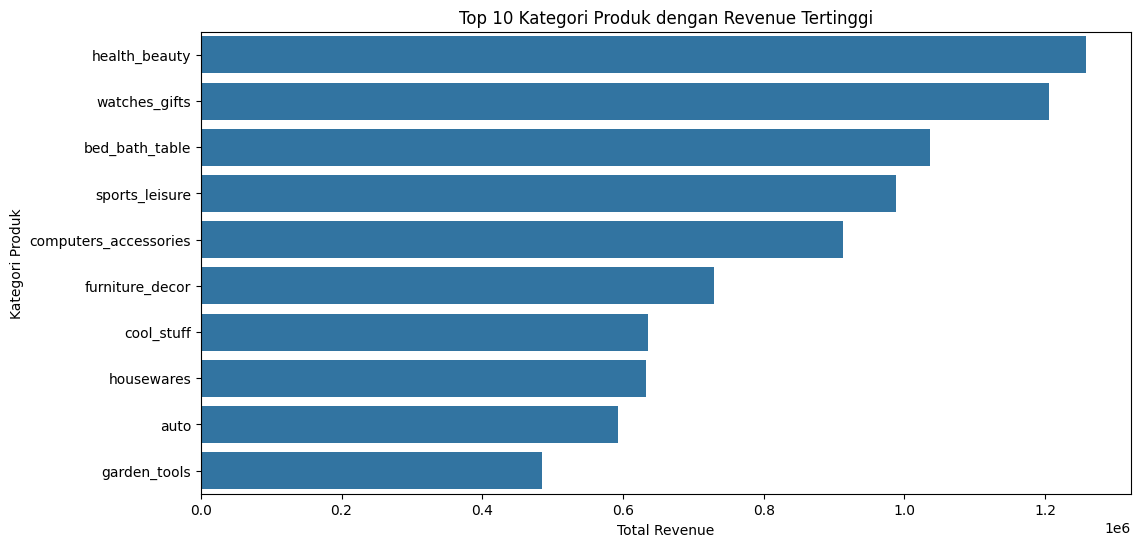

In [8]:
category_revenue_df = order_items_df.merge(products_df, on='product_id', how='left')
category_revenue_df = category_revenue_df.merge(category_df, on='product_category_name', how='left')

top_category_revenue = category_revenue_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_category_revenue.values, y=top_category_revenue.index)
plt.title('Top 10 Kategori Produk dengan Revenue Tertinggi')
plt.xlabel('Total Revenue')
plt.ylabel('Kategori Produk')
plt.show()

### Pertanyaan 2:

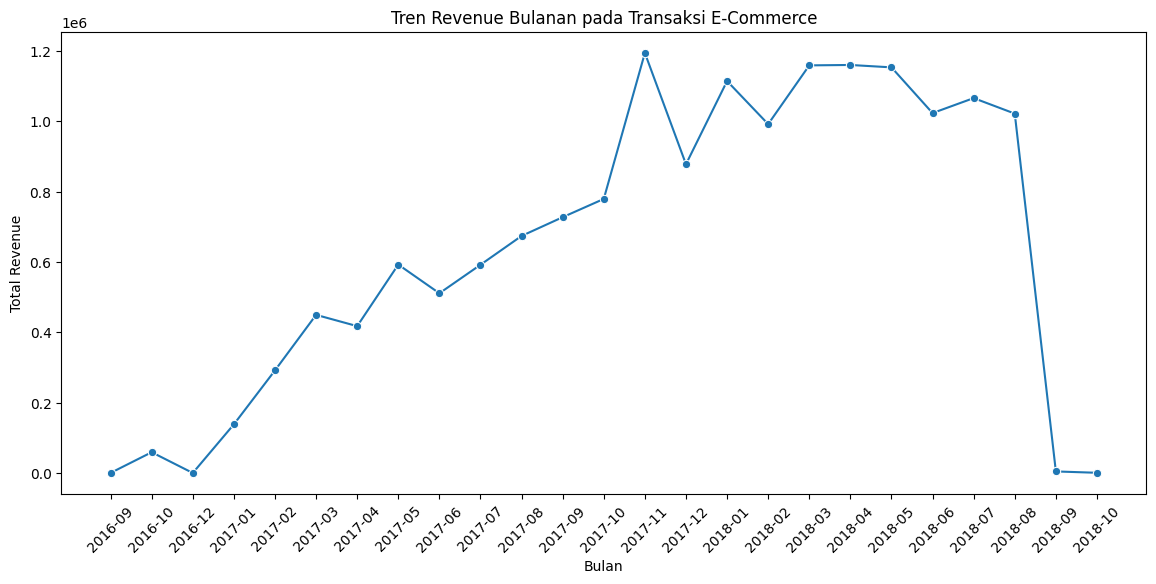

In [9]:
monthly_revenue_df = orders_df.merge(payments_df, on='order_id', how='left')

monthly_revenue_df['month_year'] = monthly_revenue_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_revenue = monthly_revenue_df.groupby('month_year')['payment_value'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x='month_year', y='payment_value', marker='o')
plt.title('Tren Revenue Bulanan pada Transaksi E-Commerce')
plt.xlabel('Bulan')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

**Insight:** Hasil visualisasi, kategori produk dengan total revenue tertinggi adalah health_beauty, diikuti oleh watches_gifts dan bed_bath_table. Kategori tersebut menjadi penyumbang revenue terbesar dalam transaksi e-commerce. Tren revenue bulanan menunjukkan peningkatan dari akhir 2016 hingga mencapai puncaknya sekitar November 2017. Pada tahun 2018, revenue masih relatif tinggi hingga Agustus, lalu menurun tajam pada bulan berikutnya.

## Analisis Lanjutan (Opsional)

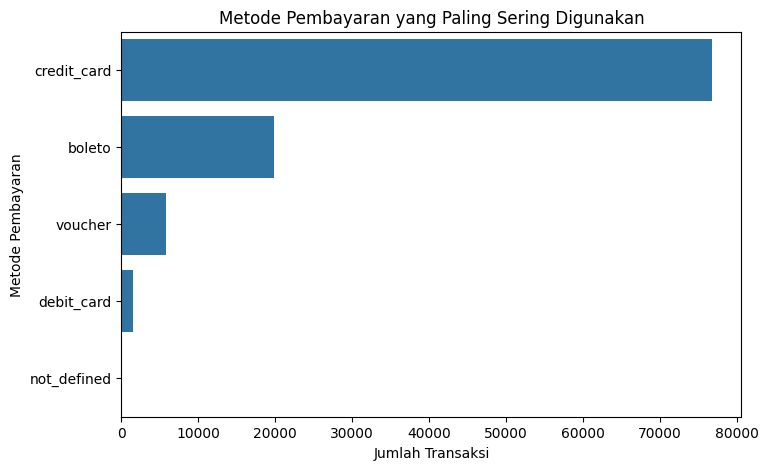

In [10]:
# Analisis tambahan: metode pembayaran yang paling sering digunakan
payment_type_count = payments_df['payment_type'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_type_count.values, y=payment_type_count.index)
plt.title('Metode Pembayaran yang Paling Sering Digunakan')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Metode Pembayaran')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori produk dengan total revenue tertinggi adalah health_beauty, diikuti oleh watches_gifts dan bed_bath_table. Kategori tersebut menjadi penyumbang utama pendapatan dalam transaksi e-commerce.
- **Conclusion pertanyaan 2:** Revenue bulanan mengalami peningkatan dari akhir 2016 hingga mencapai puncaknya sekitar November 2017. Pada tahun 2018, revenue masih relatif tinggi hingga Agustus, lalu menurun tajam pada bulan berikutnya karena kemungkinan cakupan data pada periode tersebut sudah tidak lengkap.

**Rekomendasi Action Item:**
- Bisnis dapat memprioritaskan kategori produk dengan revenue tertinggi seperti health_beauty, watches_gifts, dan bed_bath_table dalam strategi promosi.
- Perusahaan dapat memantau tren revenue bulanan untuk menentukan periode terbaik dalam menjalankan campaign atau diskon penjualan.
- Metode pembayaran credit_card dapat tetap dioptimalkan karena menjadi metode pembayaran yang paling sering digunakan pelanggan.